SST: (75001, 15) Fs= 50000 Hz  dur≈ 1.5 s
PV : (75001, 25) Fs= 50000 Hz  dur≈ 1.5 s


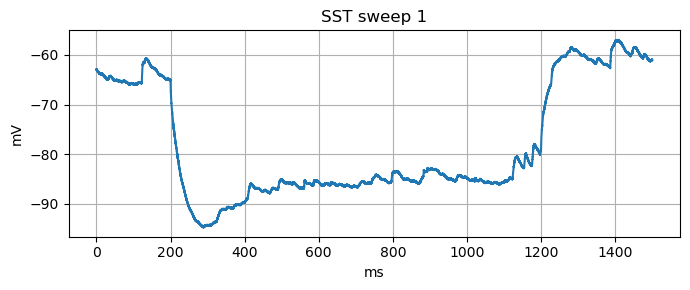

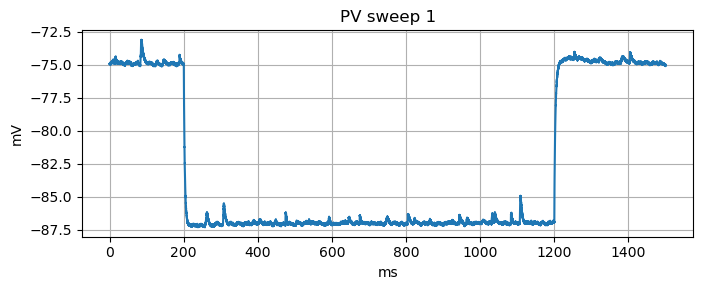

In [1]:
import pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt

pkl = "/home/hrbncv/PV-SST/single_cells/Madhu_Data/MAT_Analysis/processed/combIVData/combIVData.pkl"
with open(pkl, "rb") as f:
    D = pickle.load(f)["ivData"]

sstV, sstFs = D["sstVoltage"], int(D["sstFs"])
pvV,  pvFs  = D["pvVoltage"],  int(D["pvFs"])

# time vectors (seconds)
t_sst = np.arange(sstV.shape[0]) / sstFs
t_pv  = np.arange(pvV.shape[0])  / pvFs

print("SST:", sstV.shape, "Fs=", sstFs, "Hz  dur≈", (len(t_sst)-1)/sstFs, "s")
print("PV :", pvV.shape,  "Fs=", pvFs,  "Hz  dur≈", (len(t_pv)-1)/pvFs,  "s")

# quick preview plots (first sweep of each)
plt.figure(figsize=(7,3)); plt.plot(t_sst*1e3, sstV[:,0]*1e3); plt.xlabel("ms"); plt.ylabel("mV"); plt.title("SST sweep 1"); plt.grid(True); plt.tight_layout(); plt.show()
plt.figure(figsize=(7,3)); plt.plot(t_pv*1e3,  pvV[:,0]*1e3 ); plt.xlabel("ms"); plt.ylabel("mV"); plt.title("PV sweep 1");  plt.grid(True); plt.tight_layout(); plt.show()


In [2]:
# ----- user-tweakable defaults -----
DATASET   = "PV"      # "SST" or "PV" (used for PKL with ivData). Ignored for CSV/NPZ unless ambiguous.
SWEEP_IDX = (0,10)       # None → overlay a few sweeps; or int index (0-based) (4 is 0pA)
xlim = (200,400)
ylim = (None,None)

Using PV: shape=(75001, 25), Fs=50000.000 Hz; plotting 11 sweep(s): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


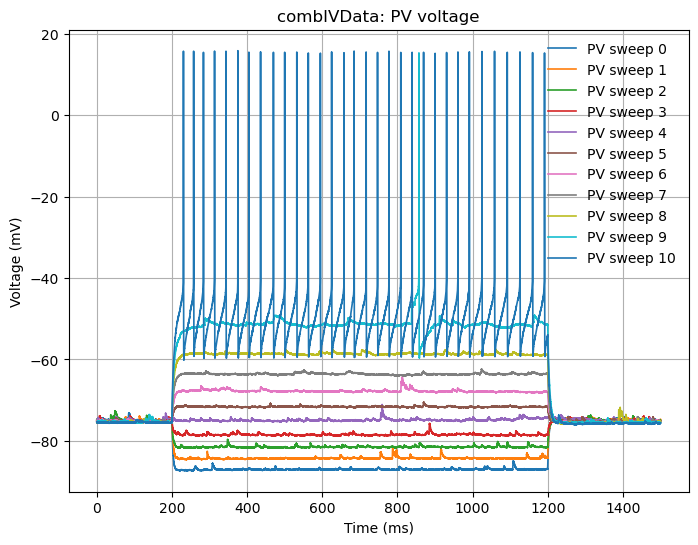

In [3]:
# Self-contained plotting cell for your inspected dataset
# - Auto-detects CSV/NPZ/PKL per your rules (priorities: CSV > NPZ > PKL)
# - Defaults to PKL ('ivData' with sst/pv) for this dataset since NPZ is empty
# - Converts time to ms and voltage to mV
# - Set DATASET={"SST","PV"} and/or SWEEP_IDX=<int> if desired

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

# ----- point to the dataset directory printed by your inspector -----
DS_DIR  = "/home/hrbncv/PV-SST/single_cells/Madhu_Data/MAT_Analysis/processed/combIVData"
STEM    = DS_DIR.rstrip("/").split("/")[-1]
CSV_FP  = f"{DS_DIR}/{STEM}.csv"
NPZ_FP  = f"{DS_DIR}/{STEM}.npz"
PKL_FP  = f"{DS_DIR}/{STEM}.pkl"

def _time_col(cols):
    lc = [c for c in cols if isinstance(c, str)]
    exact = [c for c in lc if c.lower() in ("t","time","c001_time")]
    if exact: return exact[0]
    contains = [c for c in lc if "time" in c.lower()]
    return contains[0] if contains else None

def _voltage_cols(cols):
    return [c for c in cols if isinstance(c, str) and ("voltage" in c.lower() or c.lower().endswith("_voltage"))]

def _normalize_indices(n, want):
    if n <= 0: return []
    # default: spread a few across the set
    if want is None:
        k = min(5, n)
        return np.unique(np.linspace(0, n-1, k, dtype=int)).tolist()
    # explicit list/tuple of indices
    if isinstance(want, (list, tuple)):
        # (start, end) inclusive range
        if len(want) == 2 and all(isinstance(x, (int, np.integer)) for x in want):
            a, b = want
            if a < 0: a += n
            if b < 0: b += n
            a = max(0, min(n-1, a))
            b = max(0, min(n-1, b))
            step = 1 if a <= b else -1
            return list(range(a, b + step, step))
        # otherwise treat as explicit list of indices
        out = []
        for x in want:
            if isinstance(x, (int, np.integer)):
                if x < 0: x += n
                if 0 <= x < n: out.append(int(x))
        return sorted(set(out))
    # single int
    if isinstance(want, (int, np.integer)):
        x = int(want)
        if x < 0: x += n
        return [x] if 0 <= x < n else [0]
    # fallback
    return [0]

def _plot(t_ms, Y_mV, labels, title):
    plt.figure(figsize=(8,6))
    for y, lab in zip(Y_mV, labels):
        plt.plot(t_ms, y, lw=1.2, label=lab)
    plt.xlabel("Time (ms)")
    # plt.xlim(xlim(0),xlim(1))
    plt.ylabel("Voltage (mV)")
    # plt.xlim(ylim(0),ylim(1))
    plt.title(title)
    if len(labels) > 1: plt.legend(loc="best", frameon=False)
    plt.grid(True); plt.show()

used = False

# ---- 1) Try CSV (time column + voltage columns) ----
try:
    df = pd.read_csv(CSV_FP)
    tcol = _time_col(df.columns)
    vcols = _voltage_cols(df.columns)
    if tcol is not None and vcols:
        t_ms = np.asarray(df[tcol]).astype(float).ravel() * 1e3  # seconds → ms
        idx = _normalize_indices(len(vcols), SWEEP_IDX)
        if not idx: idx = [0]
        chosen = [vcols[i] for i in idx if 0 <= i < len(vcols)]
        Y_mV = [np.asarray(df[c]).astype(float).ravel()*1e3 for c in chosen]
        _plot(t_ms, Y_mV, chosen, f"{STEM}: CSV voltages vs time")
        used = True
except Exception:
    pass

# ---- 2) Try NPZ (time array OR Fs + Voltage arrays) ----
if not used:
    try:
        with np.load(NPZ_FP) as z:
            keys = list(z.files)
            if keys:
                # time-first strategy
                tkey = next((k for k in keys if "time" in k.lower() or k.lower() in ("t","c001_time")), None)
                t = None
                if tkey is not None:
                    t = np.asarray(z[tkey]).ravel().astype(float)  # seconds
                else:
                    # Fs-based strategy (prefer sst/pv specific first)
                    Fs = None
                    for fk in ("sstFs","pvFs","Fs"):
                        if fk in z:
                            Fs = float(np.asarray(z[fk]).squeeze())
                            break
                    if Fs is not None:
                        vkey = next((k for k in keys if "voltage" in k.lower()), None)
                        if vkey is not None:
                            V = np.asarray(z[vkey])
                            T = V.shape[0]
                            t = np.arange(T, dtype=float) / Fs
                if t is not None:
                    T = t.size
                    cand = []
                    for k in keys:
                        if "voltage" in k.lower():
                            arr = np.asarray(z[k])
                            if arr.ndim == 1 and arr.size == T:
                                cand.append((k, arr[:,None]))
                            elif arr.ndim == 2 and arr.shape[0] == T:
                                cand.append((k, arr))
                    if cand:
                        name, V = cand[0]
                        n = 1 if V.ndim == 1 else V.shape[1]
                        idx = _normalize_indices(n, SWEEP_IDX)
                        if not idx: idx = [0]
                        Y = [V[:,i] for i in idx] if n > 1 else [V.squeeze()]
                        t_ms = t * 1e3
                        Y_mV = [y.astype(float)*1e3 for y in Y]
                        _plot(t_ms, Y_mV, [f"{name}[{i}]" for i in idx] if n>1 else [name],
                              f"{STEM}: NPZ {name} vs time")
                        used = True
    except Exception:
        pass

# ---- 3) PKL (nested ivData with sst/pv) ----
if not used:
    try:
        with open(PKL_FP, "rb") as f:
            obj = pickle.load(f)
        data = obj["ivData"] if isinstance(obj, dict) and "ivData" in obj else obj
        have_sst = "sstVoltage" in data and "sstFs" in data
        have_pv  = "pvVoltage"  in data and "pvFs"  in data
        if not (have_sst or have_pv):
            raise ValueError("No sst/pv voltage entries found in PKL.")
        ds = (DATASET or "SST").upper()
        if ds not in ("SST","PV"):
            ds = "SST"
        if ds == "SST" and not have_sst: ds = "PV"
        if ds == "PV" and not have_pv:  ds = "SST"
        if ds == "SST":
            V = np.asarray(data["sstVoltage"]); Fs = float(data["sstFs"]); title_base = "SST"
        else:
            V = np.asarray(data["pvVoltage"]);  Fs = float(data["pvFs"]);  title_base = "PV"
        if V.ndim == 1:
            V2 = V[:,None]; N = 1
        else:
            V2 = V; N = V2.shape[1]
        t_ms = (np.arange(V2.shape[0], dtype=float) / Fs) * 1e3
        idx = _normalize_indices(N, SWEEP_IDX)
        if not idx: idx = [0]
        Y_mV = [V2[:,i].astype(float)*1e3 for i in idx]
        labels = [f"{title_base} sweep {i}" for i in idx]
        print(f"Using {title_base}: shape={V2.shape}, Fs={Fs:.3f} Hz; plotting {len(idx)} sweep(s): {idx}")
        _plot(t_ms, Y_mV, labels, f"{STEM}: {title_base} voltage")
        used = True
    except Exception as e:
        print("[error] PKL load/plot failed:", e)

if not used:
    print("No plottable time-series detected. If you expected CSV/NPZ here, ensure filenames match STEM and contain time and voltage data.")


In [23]:

# ===== user-tweakable =====
DS_DIR          = "/home/hrbncv/PV-SST/single_cells/Madhu_Data/MAT_Analysis/processed/combIVData"  # dataset folder
DATASET         = "PV"        # "SST" or "PV" for PKL ivData
SWEEP_IDX       = (0,4)         # None | int | [i,j,...] | (start,end) inclusive

# Plot limits (None => auto)
X_LIM_MS        = None         # e.g., (0, 1000)
Y_LIM_MV        = None         # e.g., (-80, 40)
FI_X_LIM        = None         # e.g., (-100, 500)
FI_Y_LIM        = None         # e.g., (0, 120)

# Display
STRIDE          = 1            # downsample for plotting

# Spike detection & analysis window
THRESH_MV       = 0.0          # spike threshold (mV), upward crossing
REFRACT_MS      = 2.0          # refractory (ms) for counting spikes
TWIN_MS         = None         # (t0, t1) ms; if None and current available, auto-detect per sweep
I_STEP_THRESH_PA= 5.0          # step-detect threshold when auto-windowing from current

# FI mapping when no current trace available (this is your "25 pA increments from -100 pA")
SWEEP0_PA       = -100.0       # current at sweep 0 (pA)
STEP_PA         = 25.0         # increment per sweep (pA)
AMP_PER_SWEEP   = None         # optional explicit list/array of pA (len=N) overrides mapping


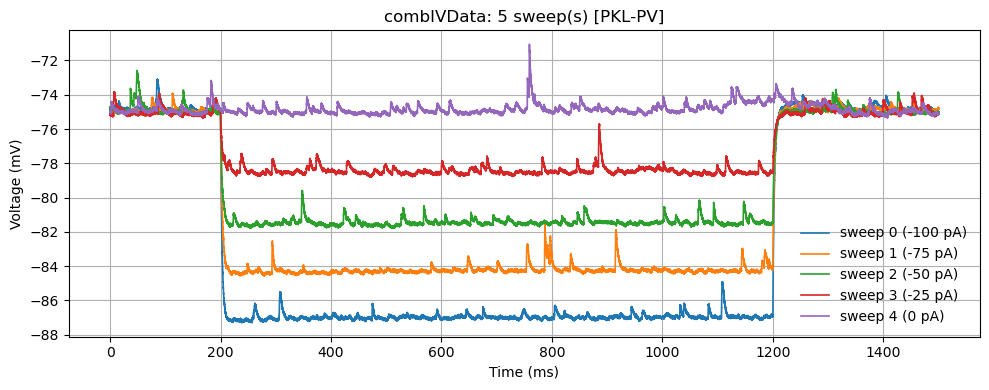

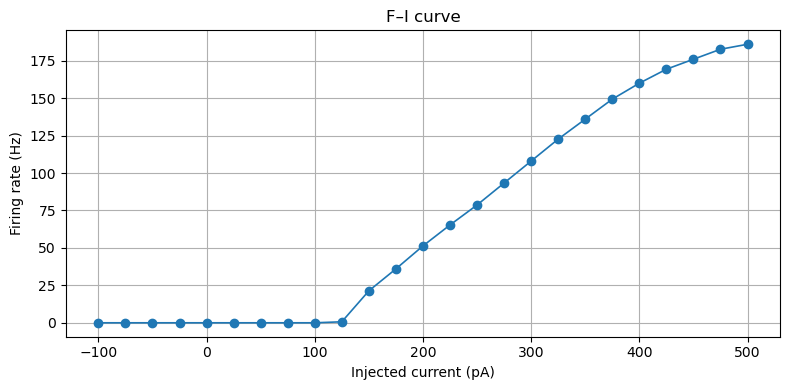

In [24]:
# Self-contained plotting cell: separate figures + FI with sweep→current mapping
# - Auto-detects CSV/NPZ/PKL (priority: CSV > NPZ > PKL[ivData])
# - Time→ms, Voltage→mV; optional Current→pA (if present)
# - SWEEP_IDX supports: None | int | [i,j,...] | (start,end) inclusive
# - In absence of current traces, maps sweep j → I0 + j*STEP (pA) (defaults below)

import os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

# ===== paths from DS_DIR =====
STEM    = os.path.basename(DS_DIR.rstrip("/"))
CSV_FP  = os.path.join(DS_DIR, f"{STEM}.csv")
NPZ_FP  = os.path.join(DS_DIR, f"{STEM}.npz")
PKL_FP  = os.path.join(DS_DIR, f"{STEM}.pkl")

# ===== helpers =====
def _time_col(cols):
    lc = [c for c in cols if isinstance(c, str)]
    exact = [c for c in lc if c.lower() in ("t","time","c001_time")]
    if exact: return exact[0]
    contains = [c for c in lc if "time" in c.lower()]
    return contains[0] if contains else None

def _voltage_cols(cols):
    return [c for c in cols if isinstance(c, str) and ("voltage" in c.lower() or c.lower().endswith("_voltage"))]

def _current_cols(cols):
    return [c for c in cols if isinstance(c, str) and ("current" in c.lower() or c.lower().endswith("_current"))]

def _num_prefix(s):
    try:
        if isinstance(s, str) and s.startswith("c") and "_" in s:
            return int(s[1:s.index("_")])
    except Exception:
        pass
    return None

def _sort_keys_nat(keys, contains):
    ks = [k for k in keys if isinstance(k, str) and contains.lower() in k.lower()]
    ks_with_num = [(k, _num_prefix(k)) for k in ks]
    ks_with_num.sort(key=lambda x: (999999 if x[1] is None else x[1], x[0]))
    return [k for k,_ in ks_with_num]

def _pair_current_for_voltage(vkey, all_keys):
    # Map 'cXYZ_Voltage_1' -> 'c{XYZ-1:03d}_Current_1' if present
    if not isinstance(vkey, str): return None
    try:
        head, tail = vkey.split("_", 1)     # 'c003', 'Voltage_1'
        num = int(head[1:])
        suffix = tail.split("_", 1)[-1]     # '1'
        cand = f"c{num-1:03d}_Current_{suffix}"
        return cand if cand in all_keys else None
    except Exception:
        return None

def _normalize_indices(n, want, k_auto=5):
    if n <= 0: return []
    if want is None:
        k = min(k_auto, n)
        return np.unique(np.linspace(0, n-1, k, dtype=int)).tolist()
    if isinstance(want, (list, tuple)):
        # (start,end) inclusive range
        if len(want) == 2 and all(isinstance(x, (int, np.integer)) for x in want):
            a, b = int(want[0]), int(want[1])
            if a < 0: a += n
            if b < 0: b += n
            a = max(0, min(n-1, a)); b = max(0, min(n-1, b))
            step = 1 if a <= b else -1
            return list(range(a, b + step, step))
        # explicit list
        out = []
        for x in want:
            if isinstance(x, (int, np.integer)):
                if x < 0: x += n
                if 0 <= x < n: out.append(int(x))
        return sorted(set(out))
    if isinstance(want, (int, np.integer)):
        x = int(want)
        if x < 0: x += n
        return [x] if 0 <= x < n else [0]
    return [0]

def _detect_step_window_from_current(t_ms, i_pA, thresh_pA=5.0):
    # return (t0, t1) ms of largest contiguous deviation from baseline; None if not found
    i_pA = np.asarray(i_pA).ravel()
    t_ms = np.asarray(t_ms).ravel()
    if i_pA.size != t_ms.size or i_pA.size < 10: return None
    n = i_pA.size
    base_n = max(1, int(0.05 * n))  # first 5% baseline
    base = i_pA[:base_n]
    med = np.median(base)
    dev = np.abs(i_pA - med)
    thr = max(thresh_pA, 5.0 * (np.median(np.abs(base - med)) + 1e-9))
    mask = dev > thr
    if not mask.any(): return None
    diff = np.diff(mask.astype(int))
    starts = np.where(diff == 1)[0] + 1
    stops  = np.where(diff == -1)[0] + 1
    if mask[0]: starts = np.r_[0, starts]
    if mask[-1]: stops = np.r_[stops, n]
    if starts.size == 0 or stops.size == 0: return None
    lengths = stops - starts
    j = np.argmax(lengths)
    return float(t_ms[starts[j]]), float(t_ms[stops[j]-1])

def _count_spikes(v_mV, t_ms, thr=0.0, refract_ms=2.0, window_ms=None):
    v = np.asarray(v_mV).ravel()
    t = np.asarray(t_ms).ravel()
    if window_ms is not None:
        t0, t1 = window_ms
        sel = (t >= t0) & (t <= t1)
        if not np.any(sel): return 0
        v = v[sel]; t = t[sel]
    if v.size < 2: return 0
    cross = (v[:-1] < thr) & (v[1:] >= thr)
    idx = np.where(cross)[0] + 1
    if idx.size == 0: return 0
    dt = np.median(np.diff(t))
    if not np.isfinite(dt) or dt <= 0: return int(idx.size)
    refr = max(1, int(np.ceil(refract_ms / dt)))
    keep = []
    last = -10**9
    for k in idx:
        if k - last >= refr:
            keep.append(k)
            last = k
    return len(keep)

def _collect_dataset():
    """Return (t_ms, V_mV (T,N), I_pA (T,N or None), source_str) or raise RuntimeError."""
    # 1) CSV
    if os.path.exists(CSV_FP):
        try:
            df = pd.read_csv(CSV_FP)
            tcol = _time_col(df.columns)
            vcols = _voltage_cols(df.columns)
            if tcol is not None and vcols:
                t_ms = df[tcol].astype(float).to_numpy() * 1e3
                vcols = sorted(vcols, key=lambda k: (_num_prefix(k) if _num_prefix(k) is not None else 999999, k))
                V = np.column_stack([df[c].astype(float).to_numpy() * 1e3 for c in vcols])
                # optional current pairing
                I = None
                ccols = []
                for vk in vcols:
                    ck = _pair_current_for_voltage(vk, df.columns)
                    ccols.append(ck)
                if any(ck is not None for ck in ccols):
                    I = []
                    for ck in ccols:
                        if ck is None:
                            I.append(np.full_like(t_ms, np.nan))
                        else:
                            I.append(df[ck].astype(float).to_numpy() * 1e12)
                    I = np.column_stack(I)
                return t_ms, V, I, "CSV"
        except Exception:
            pass
    # 2) NPZ
    if os.path.exists(NPZ_FP):
        try:
            with np.load(NPZ_FP) as z:
                keys = list(z.files)
                if keys:
                    tkey = next((k for k in keys if k.lower() in ("c001_time","time","t","c001_time")), None)
                    if tkey is None:
                        tkey = next((k for k in keys if "time" in k.lower()), None)
                    t = np.asarray(z[tkey]).ravel().astype(float) if tkey is not None else None
                    vkeys = _sort_keys_nat(keys, "Voltage")
                    V = None
                    if vkeys:
                        arrs = [np.asarray(z[k]) for k in vkeys]
                        if any(a.ndim == 2 for a in arrs):
                            A = next(a for a in arrs if a.ndim == 2)
                            V = A.astype(float) * 1e3
                            if t is None:
                                T = V.shape[0]
                                Fs = None
                                for fk in ("sstFs","pvFs","Fs"):
                                    if fk in z:
                                        Fs = float(np.asarray(z[fk]).squeeze()); break
                                if Fs is not None:
                                    t = np.arange(T, dtype=float) / Fs
                        elif t is not None:
                            V = np.column_stack([a.astype(float).ravel() for a in arrs]) * 1e3
                    if t is not None and V is not None and V.shape[0] == t.size:
                        I = None
                        ckeys = _sort_keys_nat(keys, "Current")
                        if ckeys:
                            carrs = [np.asarray(z[k]).astype(float).ravel() * 1e12 for k in ckeys]
                            if all(a.size == t.size for a in carrs):
                                I = np.column_stack(carrs)
                        return t * 1e3, V, I, "NPZ"
        except Exception:
            pass
    # 3) PKL (ivData)
    if os.path.exists(PKL_FP):
        try:
            with open(PKL_FP, "rb") as f:
                obj = pickle.load(f)
            if isinstance(obj, dict) and "ivData" in obj:
                data = obj["ivData"]
                have_sst = isinstance(data, dict) and "sstVoltage" in data and "sstFs" in data
                have_pv  = isinstance(data, dict) and "pvVoltage"  in data and "pvFs"  in data
                ds = (DATASET or "SST").upper()
                if ds not in ("SST","PV"): ds = "SST"
                if ds == "SST" and not have_sst: ds = "PV"
                if ds == "PV" and not have_pv:  ds = "SST"
                if ds == "SST":
                    V = np.asarray(data["sstVoltage"]).astype(float) * 1e3
                    Fs = float(data["sstFs"]); tag = "PKL-SST"
                else:
                    V = np.asarray(data["pvVoltage"]).astype(float) * 1e3
                    Fs = float(data["pvFs"]);  tag = "PKL-PV"
                if V.ndim == 1: V = V[:, None]
                t_ms = (np.arange(V.shape[0], dtype=float) / Fs) * 1e3
                I = None
                return t_ms, V, I, tag
            # flat dict with time/voltage keys (sanitized)
            if isinstance(obj, dict):
                clean = { (k.split("\x00",1)[0] if isinstance(k,str) else k): v for k,v in obj.items() }
                keys = list(clean.keys())
                tkey = _time_col(keys) or next((k for k in keys if isinstance(k,str) and "time" in k.lower()), None)
                vkeys = _sort_keys_nat(keys, "Voltage")
                if tkey and vkeys:
                    t = np.asarray(clean[tkey]).astype(float).ravel()
                    V = np.column_stack([np.asarray(clean[k]).astype(float).ravel() for k in vkeys]) * 1e3
                    I = None
                    ckeys = _sort_keys_nat(keys, "Current")
                    if ckeys and all(np.asarray(clean[k]).ravel().size == t.size for k in ckeys):
                        I = np.column_stack([np.asarray(clean[k]).astype(float).ravel() for k in ckeys]) * 1e12
                    return t * 1e3, V, I, "PKL"
        except Exception:
            pass
    raise RuntimeError("No plottable time-series detected. Ensure CSV/NPZ/PKL contain time + voltage.")

# ===== main =====
t_ms, V_mV, I_pA, src = _collect_dataset()
T, N = V_mV.shape[0], V_mV.shape[1]

# choose sweeps to DISPLAY (top figure)
disp_idx = _normalize_indices(N, SWEEP_IDX)
if not disp_idx: disp_idx = [0]

# ===== Figure 1: voltage traces =====
plt.figure(figsize=(10, 4))
tt = t_ms[::STRIDE]
for i in disp_idx:
    yi = V_mV[:, i][::STRIDE]
    label = f"sweep {i}"
    if I_pA is None:
        label += f" ({SWEEP0_PA + STEP_PA*i:.0f} pA)"
    plt.plot(tt, yi, lw=1.2, label=label)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title(f"{STEM}: {len(disp_idx)} sweep(s) [{src}]")
if len(disp_idx) > 1:
    plt.legend(loc="best", frameon=False)
plt.grid(True)
if X_LIM_MS is not None: plt.xlim(*X_LIM_MS)
if Y_LIM_MV is not None: plt.ylim(*Y_LIM_MV)
plt.tight_layout()
plt.show()

# ===== Figure 2: F–I curve =====
# Determine analysis window + rate and amplitude for EACH sweep
rates_hz = np.zeros(N, dtype=float)
amps_pA  = np.zeros(N, dtype=float)
x_is_current = False

for j in range(N):
    # window selection
    win = None
    if TWIN_MS is not None:
        win = (float(TWIN_MS[0]), float(TWIN_MS[1]))
    elif I_pA is not None:
        auto = _detect_step_window_from_current(t_ms, I_pA[:, j], thresh_pA=I_STEP_THRESH_PA)
        if auto is not None:
            win = auto
    # spike count and rate
    nspk = _count_spikes(V_mV[:, j], t_ms, thr=THRESH_MV, refract_ms=REFRACT_MS, window_ms=win)
    dur_s = (t_ms[-1] - t_ms[0]) / 1000.0 if win is None else max(1e-9, (win[1] - win[0]) / 1000.0)
    rates_hz[j] = nspk / dur_s
    # amplitude on x-axis
    if I_pA is not None:
        if win is None:
            base = np.median(I_pA[:max(1, int(0.05*T)), j])
            amp = np.median(I_pA[:, j]) - base
        else:
            sel = (t_ms >= win[0]) & (t_ms <= win[1])
            base = np.median(I_pA[:max(1, int(0.05*T)), j])
            amp = np.median(I_pA[sel, j]) - base
        amps_pA[j] = float(amp); x_is_current = True
    elif AMP_PER_SWEEP is not None and len(AMP_PER_SWEEP) == N:
        amps_pA[j] = float(AMP_PER_SWEEP[j]); x_is_current = True
    else:
        amps_pA[j] = SWEEP0_PA + STEP_PA * j; x_is_current = True  # ← your mapping

order = np.argsort(amps_pA)
plt.figure(figsize=(8, 4))
plt.plot(amps_pA[order], rates_hz[order], marker="o", lw=1.2)
plt.ylabel("Firing rate (Hz)")
plt.xlabel("Injected current (pA)" if x_is_current else "Sweep index")
plt.title("F–I curve")
plt.grid(True)
if FI_X_LIM is not None: plt.xlim(*FI_X_LIM)
if FI_Y_LIM is not None: plt.ylim(*FI_Y_LIM)
plt.tight_layout()
plt.show()
